# Demo: S&P 500 Forecasting & Uncertainty Quantification

End-to-end walkthrough of the pipeline:

1. **Download** the raw SPY dataset from Kaggle.
2. **Preprocess** it into chronological train/val/test sequences.
3. **Train** both models on the recommended hyperparameters.
4. **Evaluate** on the held-out test set (returns + price level, with calibrated uncertainty).
5. **Bonus: Forecast** 2025, 2026 year-to-date (plus a free-running projection to year-end), and the next trading day.

## Setup

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from src.constants import DEVICE, SEED
from src.utils.training import set_seeds

WINDOW_SIZE = 21

set_seeds(SEED)
print(f"Project root: {ROOT}")
print(f"Device: {DEVICE}")

2026-06-20 13:23:50 [INFO    ] uml - Fixed deterministic environment seeds using: 33
Project root: /home/marcusp/Documents/University of Groningen/uncertainty-in-ml
Device: cuda


## Download the data

Requires a Kaggle API token, via the `kaggle` section of `config.yaml` or `~/.kaggle/kaggle.json`. If you already have `data/raw/SPY.csv`, this can be skipped.

In [3]:
!uv run main.py download

2026-06-20 13:23:53 [INFO    ] uml - Downloading data from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/yousefeddin/s-and-p-500-stock-price-end-of-2024
2026-06-20 13:23:54 [INFO    ] uml - Data downloaded and extracted successfully.
2026-06-20 13:23:54 [INFO    ] uml - Data prepared as raw files successfully.


## Preprocess & engineer features

Computes log returns (dividend-adjusted), fits a `StandardScaler` **on the training split only** (≤ 2016), builds 4 features (scaled return, absolute return, 5-day and 21-day rolling volatility), and slices everything into 21-step windows split chronologically:

| Split | Years |
|-------|-------|
| train | ≤ 2016 |
| val   | 2017–2020 |
| test  | 2021–2024 |

Outputs `train/val/test.npz` plus the saved scaler params under `data/processed/`.

In [4]:
!uv run main.py preprocess --window-size 21 --train-end-year 2016 --val-end-year 2020

2026-06-20 13:23:58 [INFO    ] uml - Starting data preprocessing pipeline...
2026-06-20 13:23:58 [INFO    ] uml - Sorting data by date...
2026-06-20 13:23:58 [INFO    ] uml - Handling dividends...
2026-06-20 13:23:58 [INFO    ] uml - Calculating log returns...
2026-06-20 13:23:58 [INFO    ] uml - Adding time index...
2026-06-20 13:23:58 [INFO    ] uml - Fitting scaler on training data...
2026-06-20 13:23:58 [INFO    ] uml - Applying volatility feature engineering...
2026-06-20 13:23:58 [INFO    ] uml - Calculating absolute scaled returns...
2026-06-20 13:23:58 [INFO    ] uml - Calculating 5-day rolling volatility...
2026-06-20 13:23:58 [INFO    ] uml - Calculating 21-day rolling volatility...
2026-06-20 13:23:58 [INFO    ] uml - Dropping initial rows with NaN rolling metrics...
2026-06-20 13:23:58 [INFO    ] uml - Creating sequences with window size 21...
2026-06-20 13:23:58 [INFO    ] uml - Splitting sequences chronologically by target dates...
2026-06-20 13:23:58 [INFO    ] uml - Sav

## Train both models on the recommended hyperparameters

In [5]:
# Variational GP
!uv run main.py train --model vgp \
  --lr 0.014542214474659556 --batch-size 64 --num-inducing 100 \
  --epochs 100 --patience 10 --monitor NLL

2026-06-20 13:24:04 [INFO    ] uml - Fixed deterministic environment seeds using: 33
2026-06-20 13:24:04 [INFO    ] uml - Loading S&P 500 Dataset partitions...
2026-06-20 13:24:04 [INFO    ] uml - Loading train dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/train.npz...
2026-06-20 13:24:04 [INFO    ] uml - Loading val dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/val.npz...
2026-06-20 13:24:04 [INFO    ] uml - Loading test dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/test.npz...
2026-06-20 13:24:04 [INFO    ] uml - Initialising model 'vgp'...
2026-06-20 13:24:08 [INFO    ] uml - Selected 100 inducing points.
2026-06-20 13:24:09 [INFO    ] uml - Starting training loop for 100 epochs...
2026-06-20 13:24:09 [INFO    ] uml - Early stopping enabled. Monitoring 'NLL' with a patience of 10 epochs.
2026-06-20 13:24:12 [INFO    ] uml - Epoch 01/100 | Tr

In [6]:
# LSTM baseline (MC-Dropout uncertainty enabled by default with 50 samples)
!uv run main.py train --model lstm \
  --lr 0.0028824672368677117 --batch-size 32 \
  --hidden-size 128 --num-layers 3 --dropout 0.24703173405578172 \
  --epochs 100 --patience 10 --monitor NLL

2026-06-20 13:24:41 [INFO    ] uml - Fixed deterministic environment seeds using: 33
2026-06-20 13:24:41 [INFO    ] uml - Loading S&P 500 Dataset partitions...
2026-06-20 13:24:41 [INFO    ] uml - Loading train dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/train.npz...
2026-06-20 13:24:41 [INFO    ] uml - Loading val dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/val.npz...
2026-06-20 13:24:41 [INFO    ] uml - Loading test dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/test.npz...
2026-06-20 13:24:41 [INFO    ] uml - Initialising model 'lstm'...
2026-06-20 13:24:41 [INFO    ] uml - Starting training loop for 100 epochs...
2026-06-20 13:24:41 [INFO    ] uml - Early stopping enabled. Monitoring 'NLL' with a patience of 10 epochs.
2026-06-20 13:24:43 [INFO    ] uml - Epoch 01/100 | Train Loss: 1.006399 | Val NLL: -2.948808 | Val ECE: 0.161928 | Val 

## Load the trained models & predict on the test set

In [7]:
from torch.utils.data import DataLoader
from src.data.dataset import SPYDataset
from src.models.base_model import BaseModel
from src.training.evaluate import _rebuild_lstm, _rebuild_vgp
from src.training.trainer import Trainer
from src.utils.scaling import SPYScaler
from src.constants import MODELS_DIR

train_ds = SPYDataset(split="train", device=DEVICE)
val_ds = SPYDataset(split="val", device=DEVICE)
test_ds = SPYDataset(split="test", device=DEVICE)

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

scaler = SPYScaler()

vgp = _rebuild_vgp(MODELS_DIR / "VariationalGP.pt")
lstm = _rebuild_lstm(MODELS_DIR / "LSTM.pt", mc_samples=50)

print("Models loaded.")

2026-06-20 13:25:05 [INFO    ] uml - Loading train dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/train.npz...
2026-06-20 13:25:05 [INFO    ] uml - Loading val dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/val.npz...
2026-06-20 13:25:05 [INFO    ] uml - Loading test dataset from /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/data/processed/test.npz...
Models loaded.


In [8]:
def evaluate_and_predict(
    model: BaseModel,
) -> tuple[dict[str, float], dict[str, np.ndarray]]:
    """Fit LSTM noise on val, score the test set, and return test predictions."""
    trainer = Trainer(model, val_loader, val_loader, test_loader, device=DEVICE)
    trainer.evaluate(use_test=False)
    test_metrics = trainer.evaluate(use_test=True, fit_noise=False)
    results = trainer.get_predictions(test_loader)
    trainer.close()
    return test_metrics, results


vgp_metrics, vgp_test = evaluate_and_predict(vgp)
lstm_metrics, lstm_test = evaluate_and_predict(lstm)

pd.DataFrame({"VariationalGP": vgp_metrics, "LSTM": lstm_metrics}).round(5)

,VariationalGP,LSTM
RMSE,0.01038,0.01039
Hit_Rate,51.59363,54.58167
NLL,-3.11016,-3.11439
ECE,0.11348,0.10767


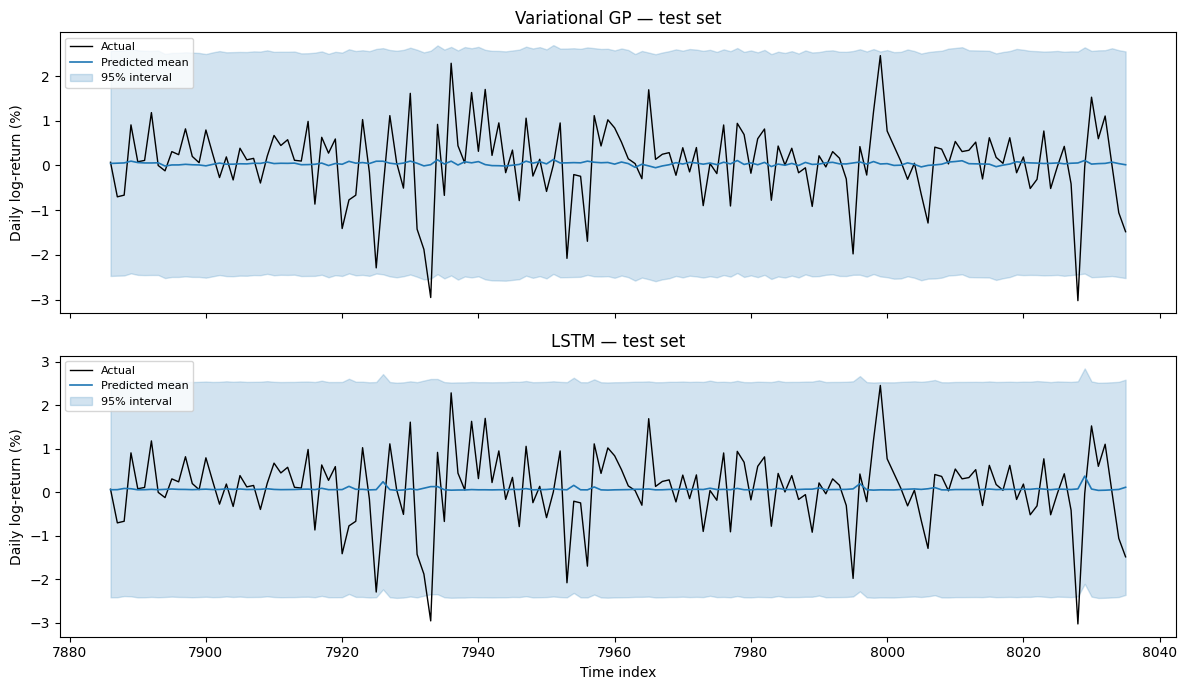

In [9]:
def plot_forecast(
    ax: plt.Axes,
    x: np.ndarray | pd.DatetimeIndex,
    results_or_tuple: dict[str, np.ndarray]
    | tuple[np.ndarray, np.ndarray, np.ndarray],
    title: str,
    max_points: int = 150,
) -> None:
    """Plot predicted next-day return (%) with a 95% band against the truth."""
    if isinstance(results_or_tuple, dict):
        mean = scaler.inverse_transform_predictions(results_or_tuple["means"])
        std = scaler.inverse_transform_std(
            np.sqrt(results_or_tuple["variances"])
        )
        target = scaler.inverse_transform_predictions(
            results_or_tuple["targets"]
        )
    else:
        mean, std, target = results_or_tuple

    sl = slice(-max_points, None)
    xs = x[sl]
    mean, std, target = mean[sl] * 100, std[sl] * 100, target[sl] * 100

    ax.plot(xs, target, color="black", lw=1.0, label="Actual")
    ax.plot(xs, mean, color="tab:blue", lw=1.2, label="Predicted mean")
    ax.fill_between(
        xs,
        mean - 1.96 * std,
        mean + 1.96 * std,
        color="tab:blue",
        alpha=0.2,
        label="95% interval",
    )
    ax.set_title(title)
    ax.set_ylabel("Daily log-return (%)")
    ax.legend(loc="upper left", fontsize=8)


fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
plot_forecast(
    axes[0], vgp_test["time_idx"], vgp_test, "Variational GP — test set"
)
plot_forecast(axes[1], lstm_test["time_idx"], lstm_test, "LSTM — test set")
axes[1].set_xlabel("Time index")
fig.tight_layout()
plt.show()

### Test-set price-level predictions

2026-06-20 13:25:10 [INFO    ] uml - Sorting data by date...
2026-06-20 13:25:10 [INFO    ] uml - Handling dividends...
2026-06-20 13:25:10 [INFO    ] uml - Calculating log returns...
2026-06-20 13:25:10 [INFO    ] uml - Adding time index...
2026-06-20 13:25:10 [INFO    ] uml - Saved price predictions visualisation to: /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/results/VariationalGP_price_predictions.png


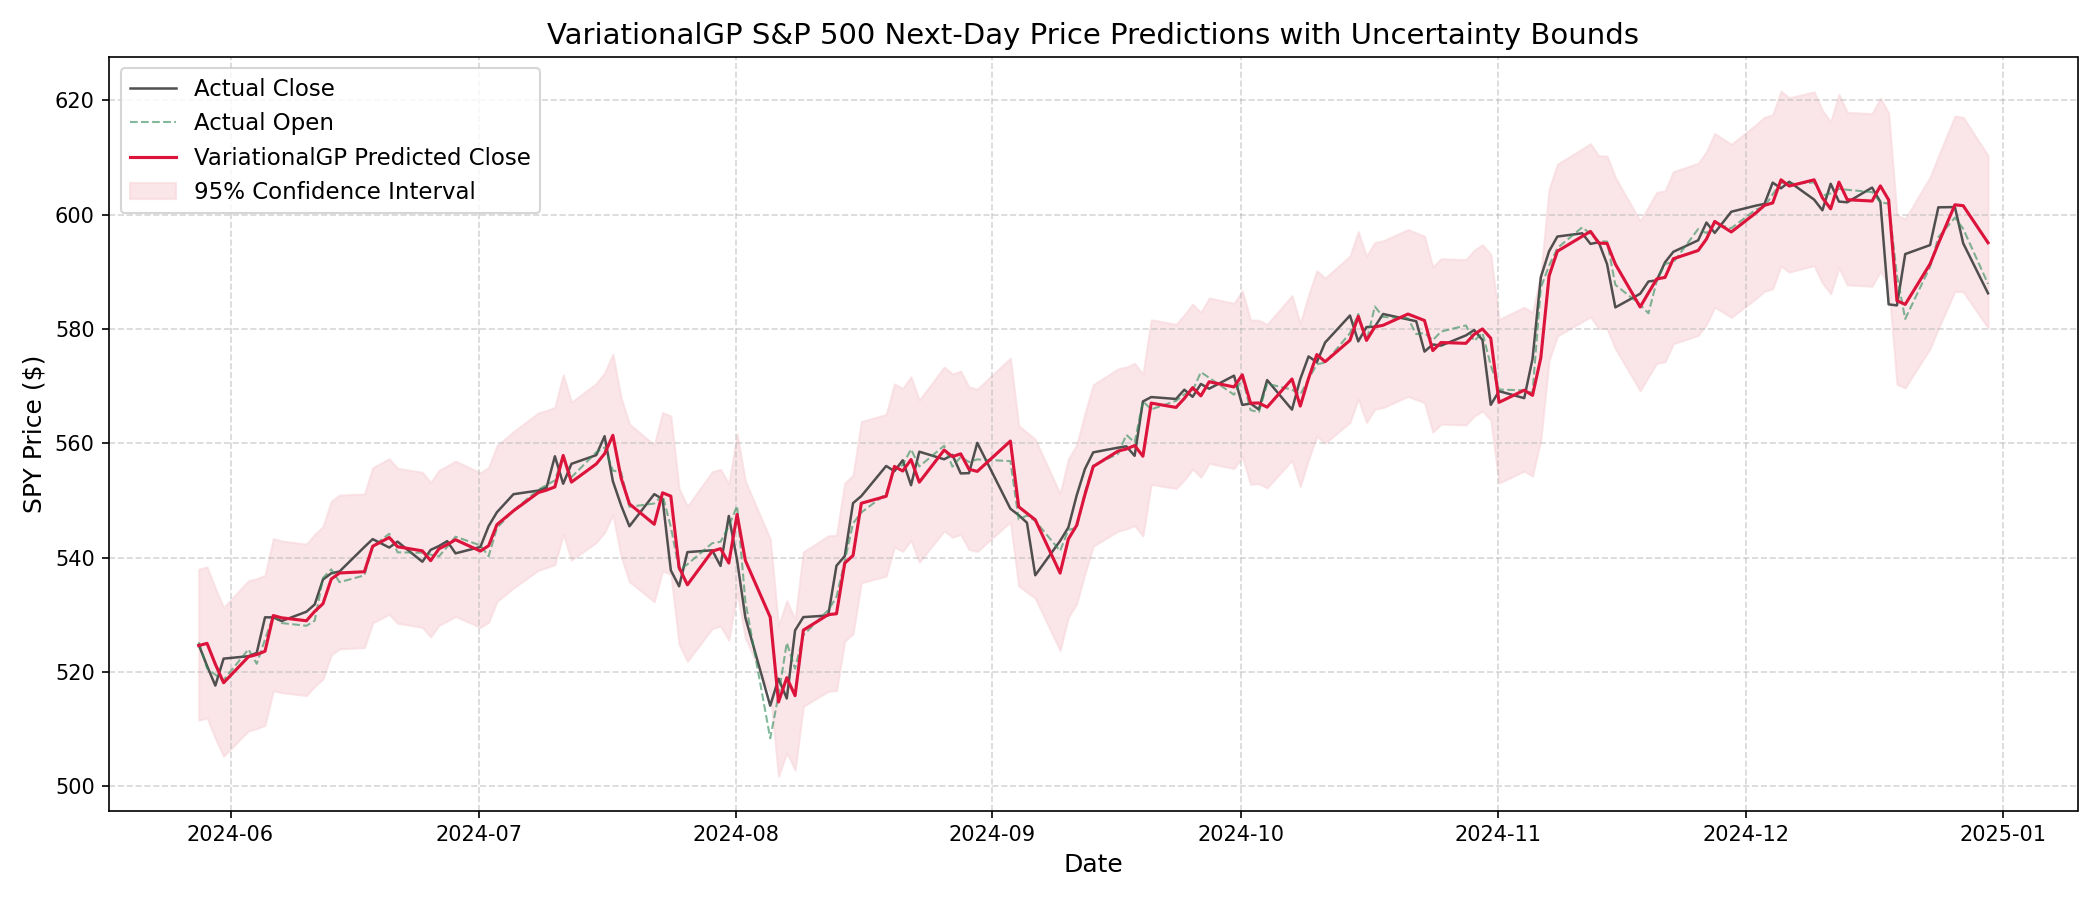

2026-06-20 13:25:11 [INFO    ] uml - Saved price predictions visualisation to: /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/results/LSTM_price_predictions.png


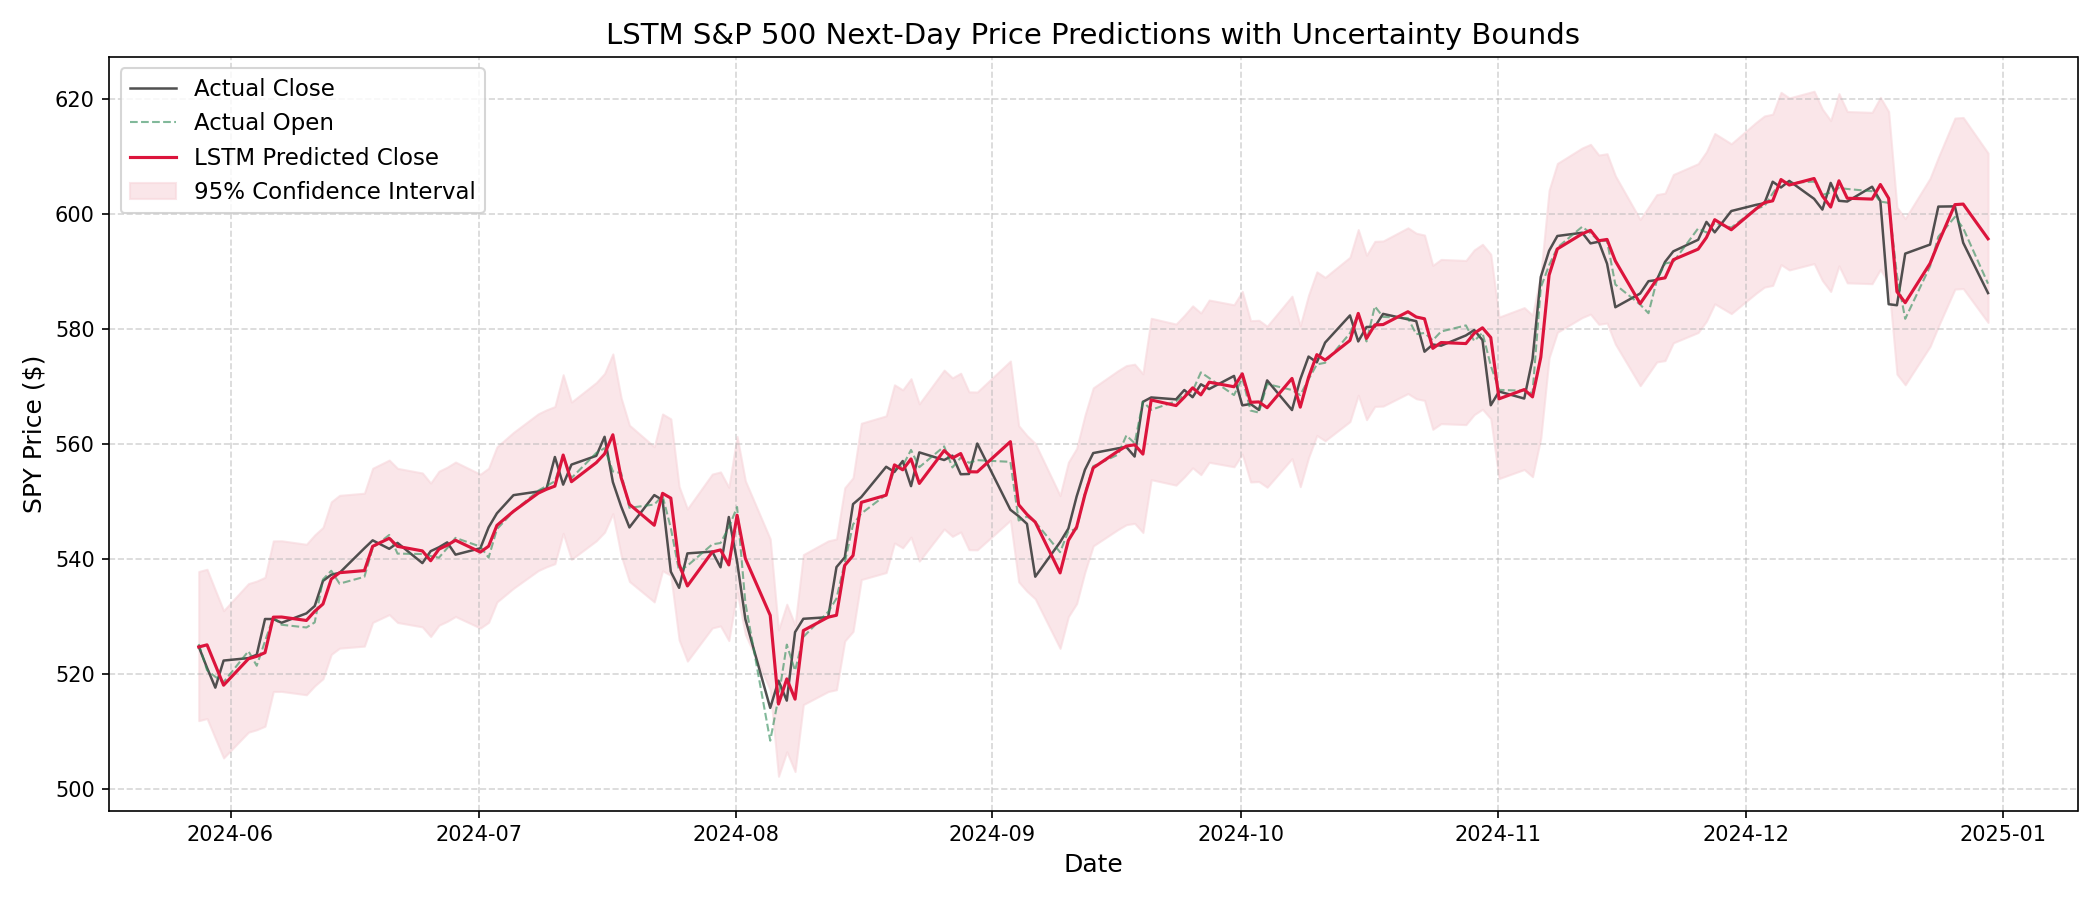

In [10]:
from IPython.display import Image, display

from src.constants import RESULTS_DIR
from src.features.spy_preprocessor import load_prices_by_time_index
from src.utils import plotting

prices = load_prices_by_time_index()

for name, res in [("VariationalGP", vgp_test), ("LSTM", lstm_test)]:
    t = res["time_idx"].astype(int)
    plotting.plot_price_predictions(
        name,
        res,
        scaler,
        prev_close=prices["Close"].reindex(t - 1).to_numpy(),
        actual_open=prices["Open"].reindex(t).to_numpy(),
        dates=prices["Date"].reindex(t).to_numpy(),
    )
    display(Image(filename=str(RESULTS_DIR / f"{name}_price_predictions.png")))

## (Bonus) Forecasting 2025

We pull 2025 with `yfinance` and run it through the identical preprocessing.

Two things are essential for the forecast to be valid:

1. **Reuse the saved scaler.** We must *not* refit on 2025, or the model would see a distribution shift it was never calibrated for.
2. **Fetch a lead-in buffer from late 2024.** The first 2025 prediction needs a full 21-day input window, and the rolling-volatility features need another ~21-day lookback. We fetch from `2024-09-01` and then keep only target dates that fall in 2025.

In [11]:
import yfinance as yf


def fetch_spy(start: str, end: str) -> pd.DataFrame:
    df = yf.Ticker("SPY").history(start=start, end=end, auto_adjust=False)
    df = df.reset_index()
    cols = ["Date", "Open", "High", "Low", "Close", "Volume", "Dividends"]
    return df[cols]


def build_year_sequences(
    df: pd.DataFrame,
    scaler: SPYScaler,
    window_size: int = WINDOW_SIZE,
    year: int = 2025,
) -> tuple[torch.Tensor, np.ndarray, pd.DatetimeIndex]:
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], utc=True)
    df = df.sort_values("Date").reset_index(drop=True)

    div = df["Dividends"].fillna(0.0)
    df["Log_Return"] = np.log((df["Close"] + div) / df["Close"].shift(1))
    df = df.dropna().reset_index(drop=True)

    df["Scaled_Log_Return"] = (df["Log_Return"] - scaler.mean) / scaler.scale

    df["Abs_Log_Return"] = df["Scaled_Log_Return"].abs()
    df["Vol_5d"] = df["Scaled_Log_Return"].rolling(5).std()
    df["Vol_21d"] = df["Scaled_Log_Return"].rolling(21).std()
    df = df.dropna().reset_index(drop=True)

    feats = ["Scaled_Log_Return", "Abs_Log_Return", "Vol_5d", "Vol_21d"]
    fv, tv, dv = (
        df[feats].values,
        df["Scaled_Log_Return"].values,
        df["Date"].values,
    )
    X, y, dates = [], [], []
    for i in range(len(df) - window_size):
        X.append(fv[i : i + window_size])
        y.append(tv[i + window_size])
        dates.append(dv[i + window_size])

    X = np.array(X)
    y = np.array(y)
    dates = pd.DatetimeIndex(pd.to_datetime(np.array(dates)))
    mask = (pd.Series(dates).dt.year == year).to_numpy()
    X_t = torch.tensor(X[mask], dtype=torch.float32, device=DEVICE)
    return X_t, y[mask], dates[mask]


raw_2025 = fetch_spy("2024-09-01", "2026-01-01")
X_2025, y_2025, dates_2025 = build_year_sequences(raw_2025, scaler, year=2025)
print(
    f"2025 trading days to forecast: {len(dates_2025)} "
    f"({dates_2025.min().date()} -> {dates_2025.max().date()})"
)

2025 trading days to forecast: 250 (2025-01-02 -> 2025-12-31)


In [12]:
def predict_raw(
    model: BaseModel, X: torch.Tensor
) -> tuple[np.ndarray, np.ndarray]:
    dist = model.forward_pass(X)
    mean = dist.mean.detach().cpu().numpy()
    std = np.sqrt(dist.variance.detach().cpu().numpy())
    return (
        np.asarray(scaler.inverse_transform_predictions(mean)),
        np.asarray(scaler.inverse_transform_std(std)),
    )


vgp_mean, vgp_std = predict_raw(vgp, X_2025)
lstm_mean, lstm_std = predict_raw(lstm, X_2025)
y_true_raw = np.asarray(scaler.inverse_transform_predictions(y_2025))


def score(
    mean: np.ndarray, std: np.ndarray, target: np.ndarray
) -> dict[str, float]:
    rmse = float(np.sqrt(np.mean(((mean - target) * 100) ** 2)))  # in %
    hit = float(np.mean(np.sign(mean) == np.sign(target)) * 100)
    coverage = float(np.mean(np.abs(target - mean) <= 1.96 * std) * 100)
    width = float(np.mean(2 * 1.96 * std) * 100)
    return {
        "RMSE (%)": rmse,
        "Hit Rate (%)": hit,
        "95% coverage (%)": coverage,
        "Mean 95% width (%)": width,
    }


pd.DataFrame(
    {
        "VariationalGP": score(vgp_mean, vgp_std, y_true_raw),
        "LSTM": score(lstm_mean, lstm_std, y_true_raw),
    }
).round(4)

,VariationalGP,LSTM
RMSE (%),1.2149,1.2249
Hit Rate (%),57.6000,57.2000
95% coverage (%),97.2000,96.8000
Mean 95% width (%),5.0725,4.9464


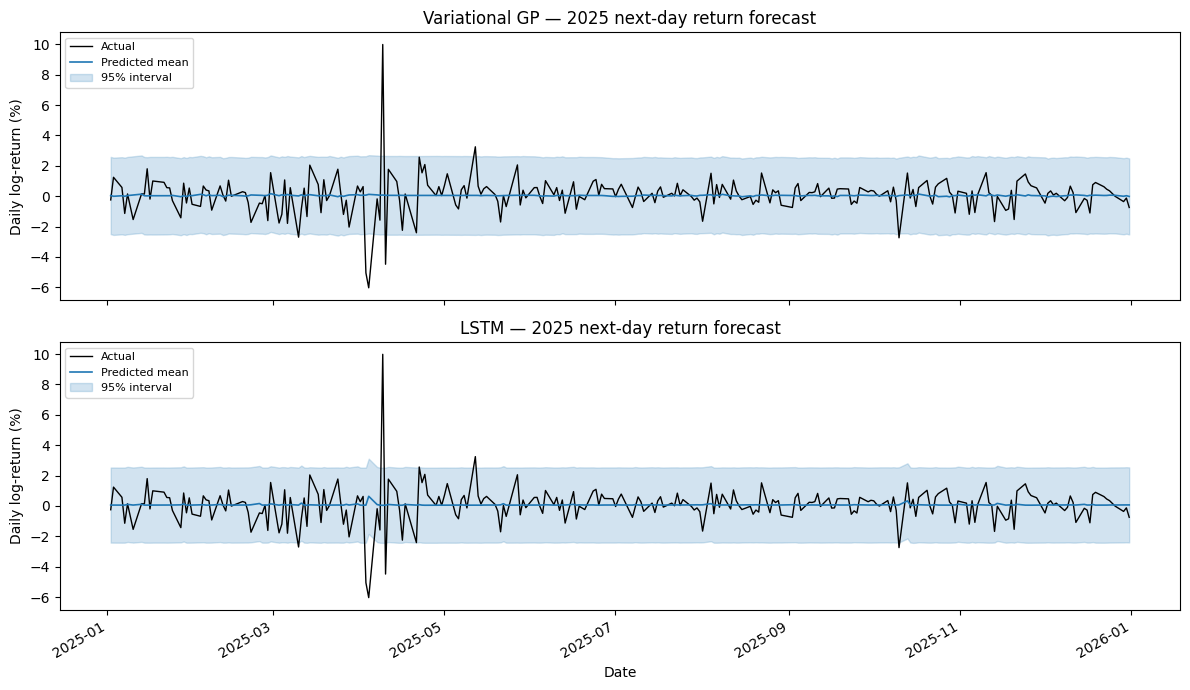

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
plot_forecast(
    axes[0],
    dates_2025,
    (vgp_mean, vgp_std, y_true_raw),
    "Variational GP — 2025 next-day return forecast",
    max_points=len(dates_2025),
)
plot_forecast(
    axes[1],
    dates_2025,
    (lstm_mean, lstm_std, y_true_raw),
    "LSTM — 2025 next-day return forecast",
    max_points=len(dates_2025),
)
axes[1].set_xlabel("Date")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

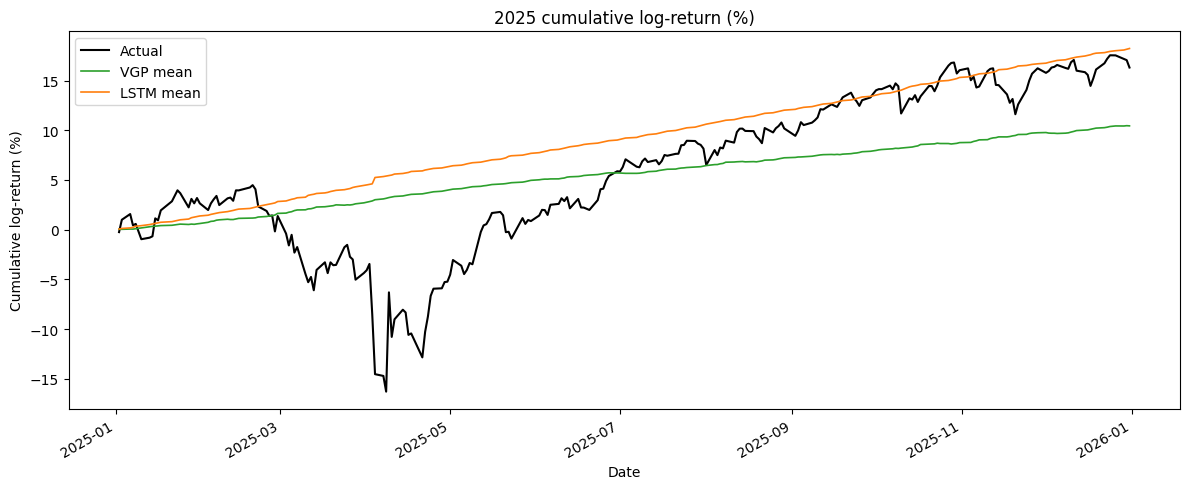

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    dates_2025,
    np.cumsum(y_true_raw) * 100,
    color="black",
    lw=1.5,
    label="Actual",
)
ax.plot(
    dates_2025,
    np.cumsum(vgp_mean) * 100,
    color="tab:green",
    lw=1.2,
    label="VGP mean",
)
ax.plot(
    dates_2025,
    np.cumsum(lstm_mean) * 100,
    color="tab:orange",
    lw=1.2,
    label="LSTM mean",
)
ax.set_title("2025 cumulative log-return (%)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative log-return (%)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

The models forecast next-day log returns, but the price follows directly. Since `r_t = log(P_t / P_{t-1})`, the predicted close is

`P_t = P_{t-1} · exp(r_t)`,

and because `exp` is monotonic the 95% return interval maps straight onto a 95% price interval. We anchor each day on the actual previous close `P_{t-1}`.

VariationalGP: price RMSE $6.86 | 95% coverage 97.2%
2026-06-20 13:25:13 [INFO    ] uml - Saved price predictions visualisation to: /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/results/VariationalGP_2025_price_predictions.png


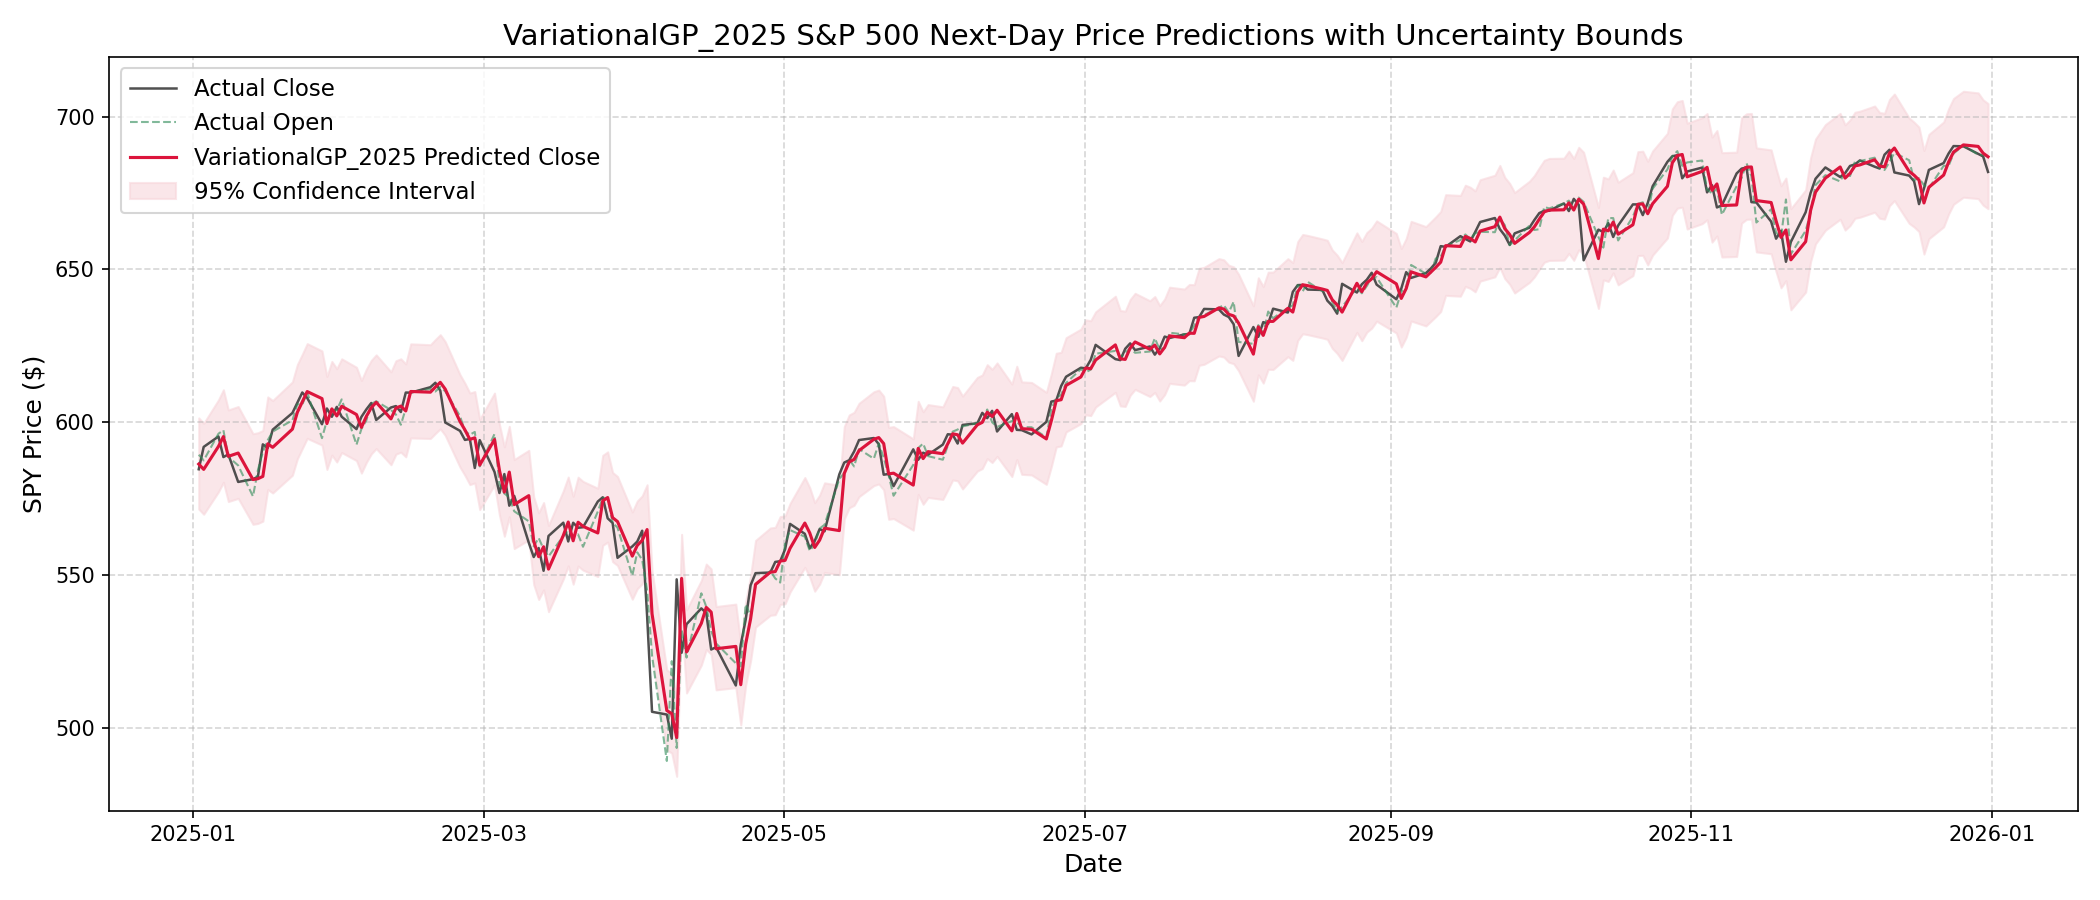

LSTM: price RMSE $6.91 | 95% coverage 96.8%
2026-06-20 13:25:13 [INFO    ] uml - Saved price predictions visualisation to: /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/results/LSTM_2025_price_predictions.png


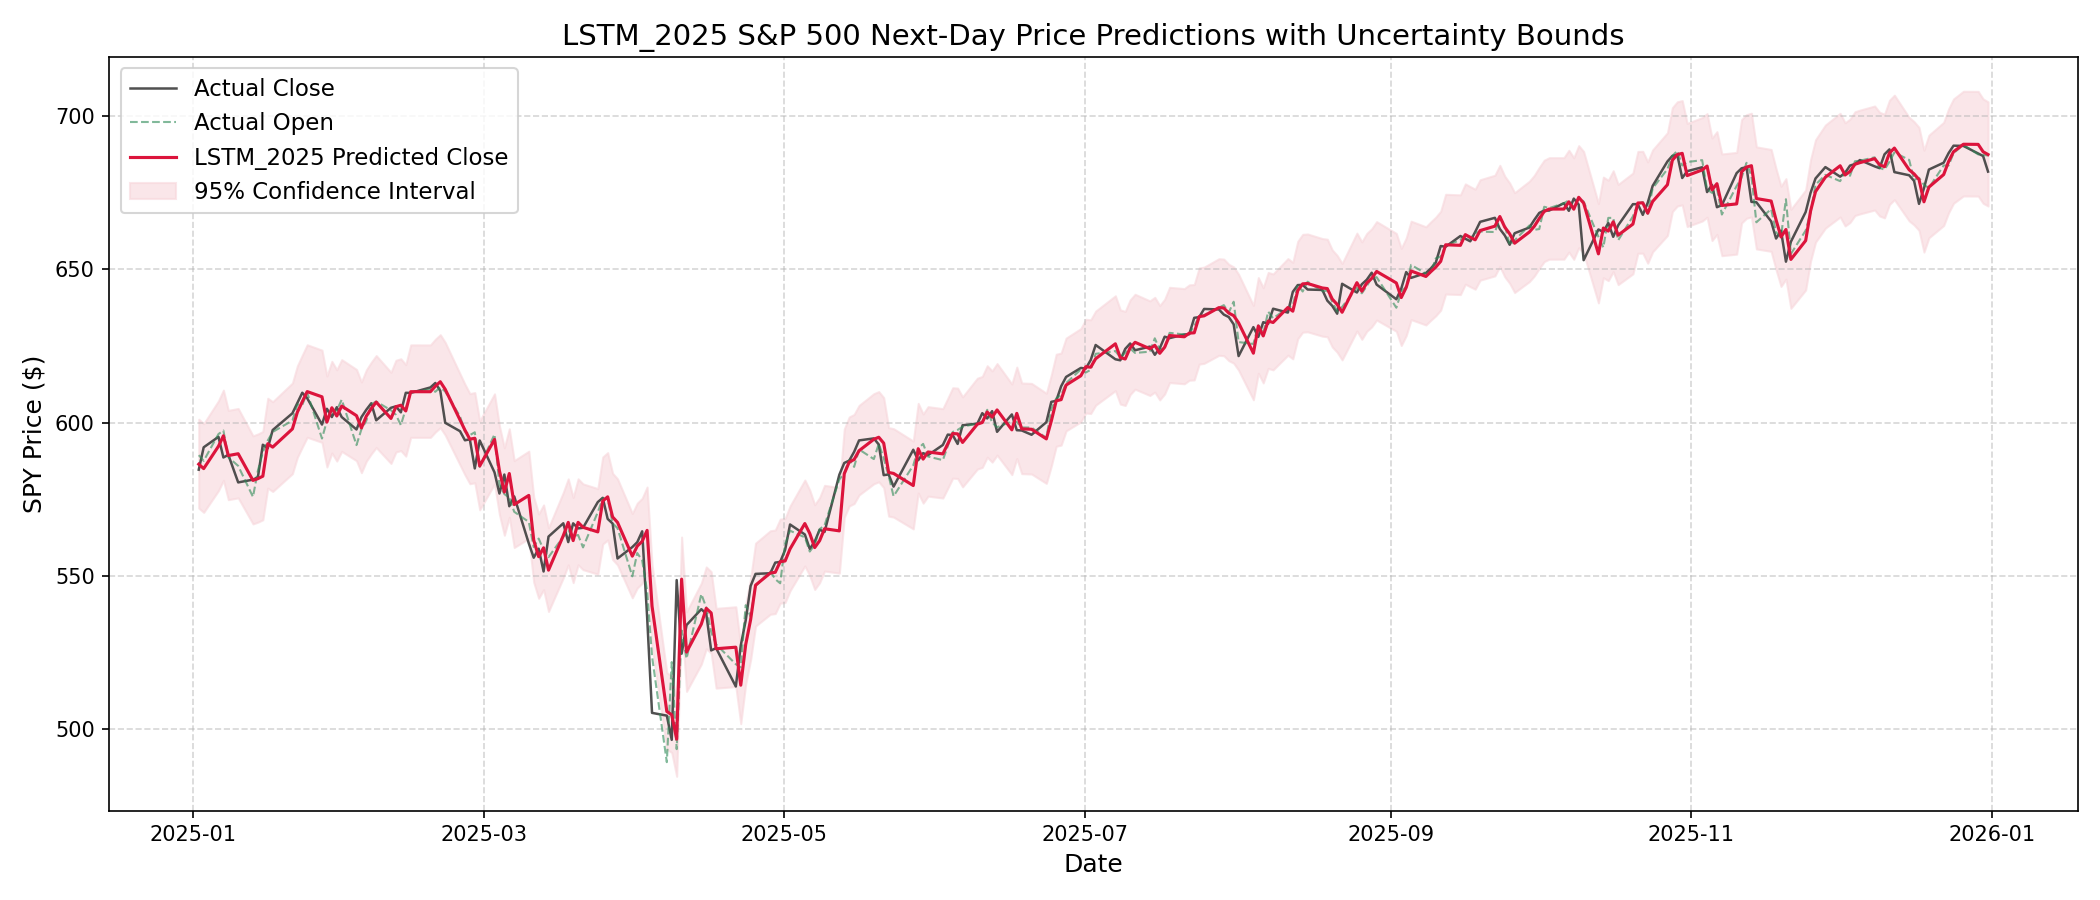

In [15]:
def aligned_prices(
    raw_df: pd.DataFrame, target_dates: pd.DatetimeIndex
) -> tuple[np.ndarray, np.ndarray]:
    """Previous close and actual open aligned to each target date (by date)."""
    p = raw_df.copy()
    p["Date"] = pd.to_datetime(p["Date"], utc=True)
    p = p.sort_values("Date").reset_index(drop=True)
    p["Prev_Close"] = p["Close"].shift(1)
    by_date = p.set_index(p["Date"].dt.date)
    sel = by_date.loc[pd.Series(target_dates).dt.date]
    return sel["Prev_Close"].to_numpy(), sel["Open"].to_numpy()


def scaled_results(
    model: BaseModel, X: torch.Tensor, y_scaled: np.ndarray
) -> dict[str, np.ndarray]:
    """A get_predictions()-style dict (in scaled space) for plotting helpers."""
    dist = model.forward_pass(X)
    return {
        "means": dist.mean.detach().cpu().numpy(),
        "variances": dist.variance.detach().cpu().numpy(),
        "targets": np.asarray(y_scaled),
        "time_idx": np.arange(len(y_scaled)),
    }


prev_close, actual_open = aligned_prices(raw_2025, dates_2025)

for name, model in [("VariationalGP", vgp), ("LSTM", lstm)]:
    results = scaled_results(model, X_2025, y_2025)

    raw_mean = np.asarray(
        scaler.inverse_transform_predictions(results["means"])
    )
    raw_std = np.asarray(
        scaler.inverse_transform_std(np.sqrt(results["variances"]))
    )
    raw_target = np.asarray(
        scaler.inverse_transform_predictions(results["targets"])
    )
    pred_close = prev_close * np.exp(raw_mean)
    actual_close = prev_close * np.exp(raw_target)
    lo, hi = (
        prev_close * np.exp(raw_mean - 1.96 * raw_std),
        prev_close * np.exp(raw_mean + 1.96 * raw_std),
    )
    rmse = float(np.sqrt(np.mean((pred_close - actual_close) ** 2)))
    cover = float(np.mean((actual_close >= lo) & (actual_close <= hi)) * 100)
    print(f"{name}: price RMSE ${rmse:.2f} | 95% coverage {cover:.1f}%")

    plotting.plot_price_predictions(
        f"{name}_2025",
        results,
        scaler,
        prev_close,
        actual_open=actual_open,
        dates=dates_2025.to_numpy(),
        max_points=len(dates_2025),
    )
    display(
        Image(filename=str(RESULTS_DIR / f"{name}_2025_price_predictions.png"))
    )

## (Bonus) Forecasting the current year (2026) so far

Only the elapsed part of the year appears as each prediction still needs a real, observed 21-day window for its target day, so days that haven't traded yet can't be produced this way. We show it in three ways:

1. **Returns:** Predicted next-day return with its 95% confidence interval (presented as predictions; the band is the point).
2. **Price level:** The same forecast lifted into dollars (`P_t = P_{t-1}·exp(r_t)`), predicted close vs. the actual close so far, with the 95% band.
3. **Year-end projection:** A free-running Monte-Carlo rollout that lets the model run to 31 Dec.

2026: 116 trading days predicted (2026-01-02 -> 2026-06-18)


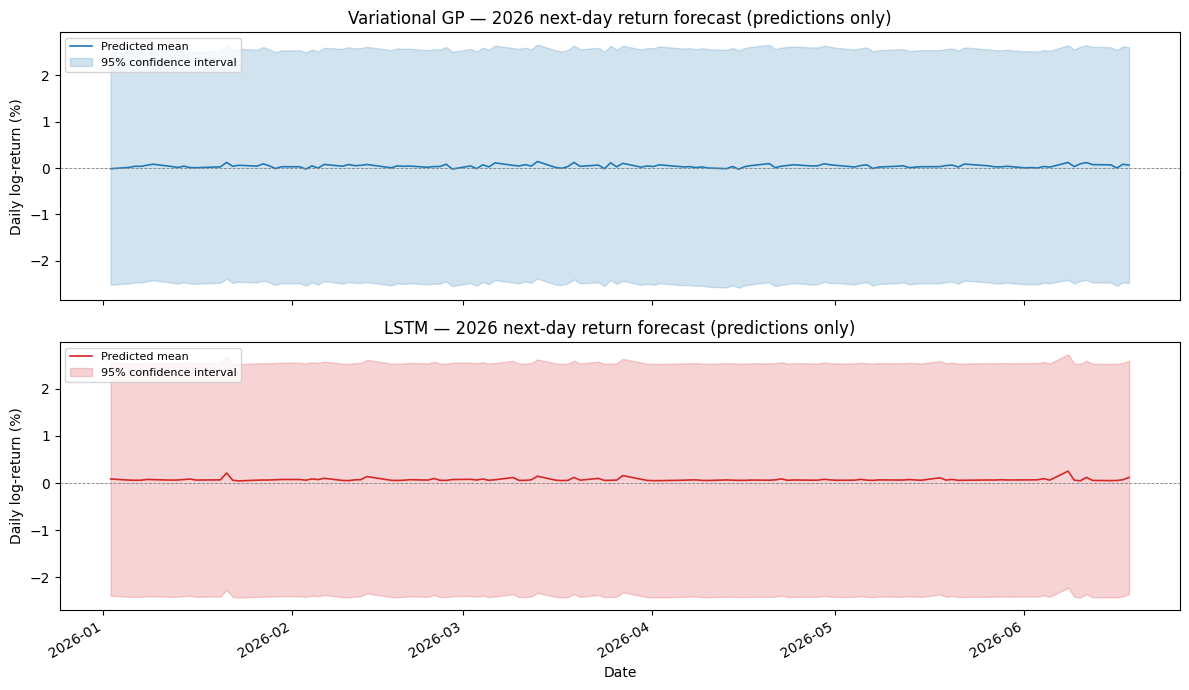

In [16]:
today = pd.Timestamp.now("UTC").normalize()
current_year = today.year

raw_cur = fetch_spy(
    f"{current_year - 1}-09-01",
    (today + pd.Timedelta(days=1)).date().isoformat(),
)
X_cur, _, dates_cur = build_year_sequences(raw_cur, scaler, year=current_year)

cur_vgp_mean, cur_vgp_std = predict_raw(vgp, X_cur)
cur_lstm_mean, cur_lstm_std = predict_raw(lstm, X_cur)

print(
    f"{current_year}: {len(dates_cur)} trading days predicted "
    f"({dates_cur.min().date()} -> {dates_cur.max().date()})"
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
panels = [
    ("Variational GP", cur_vgp_mean, cur_vgp_std, "tab:blue"),
    ("LSTM", cur_lstm_mean, cur_lstm_std, "tab:red"),
]
for ax, (name, mean, std, color) in zip(axes, panels):
    ax.plot(dates_cur, mean * 100, color=color, lw=1.2, label="Predicted mean")
    ax.fill_between(
        dates_cur,
        (mean - 1.96 * std) * 100,
        (mean + 1.96 * std) * 100,
        color=color,
        alpha=0.2,
        label="95% confidence interval",
    )
    ax.axhline(0.0, color="grey", lw=0.6, ls="--")
    ax.set_title(
        f"{name} — {current_year} next-day return forecast (predictions only)"
    )
    ax.set_ylabel("Daily log-return (%)")
    ax.legend(loc="upper left", fontsize=8)
axes[1].set_xlabel("Date")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

2026-06-20 13:25:14 [INFO    ] uml - Saved price predictions visualisation to: /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/results/VariationalGP_2026_price_predictions.png


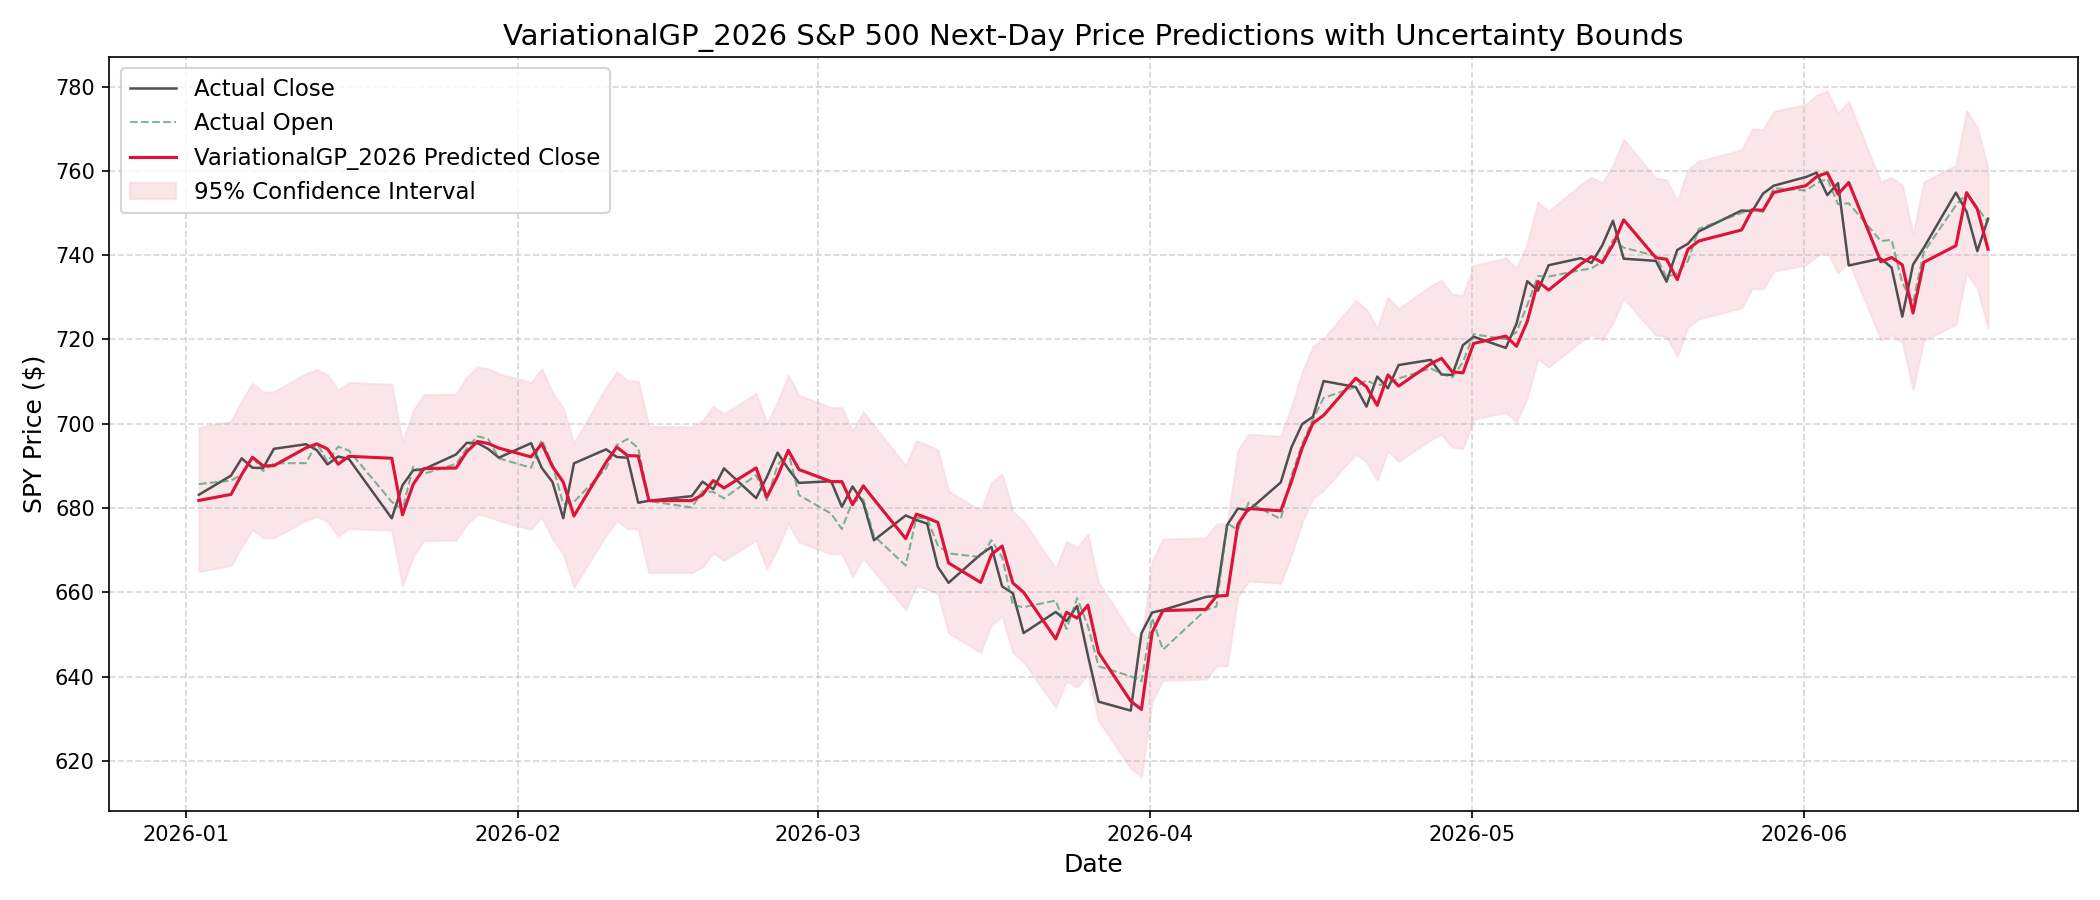

2026-06-20 13:25:15 [INFO    ] uml - Saved price predictions visualisation to: /home/marcusp/Documents/University of Groningen/uncertainty-in-ml/results/LSTM_2026_price_predictions.png


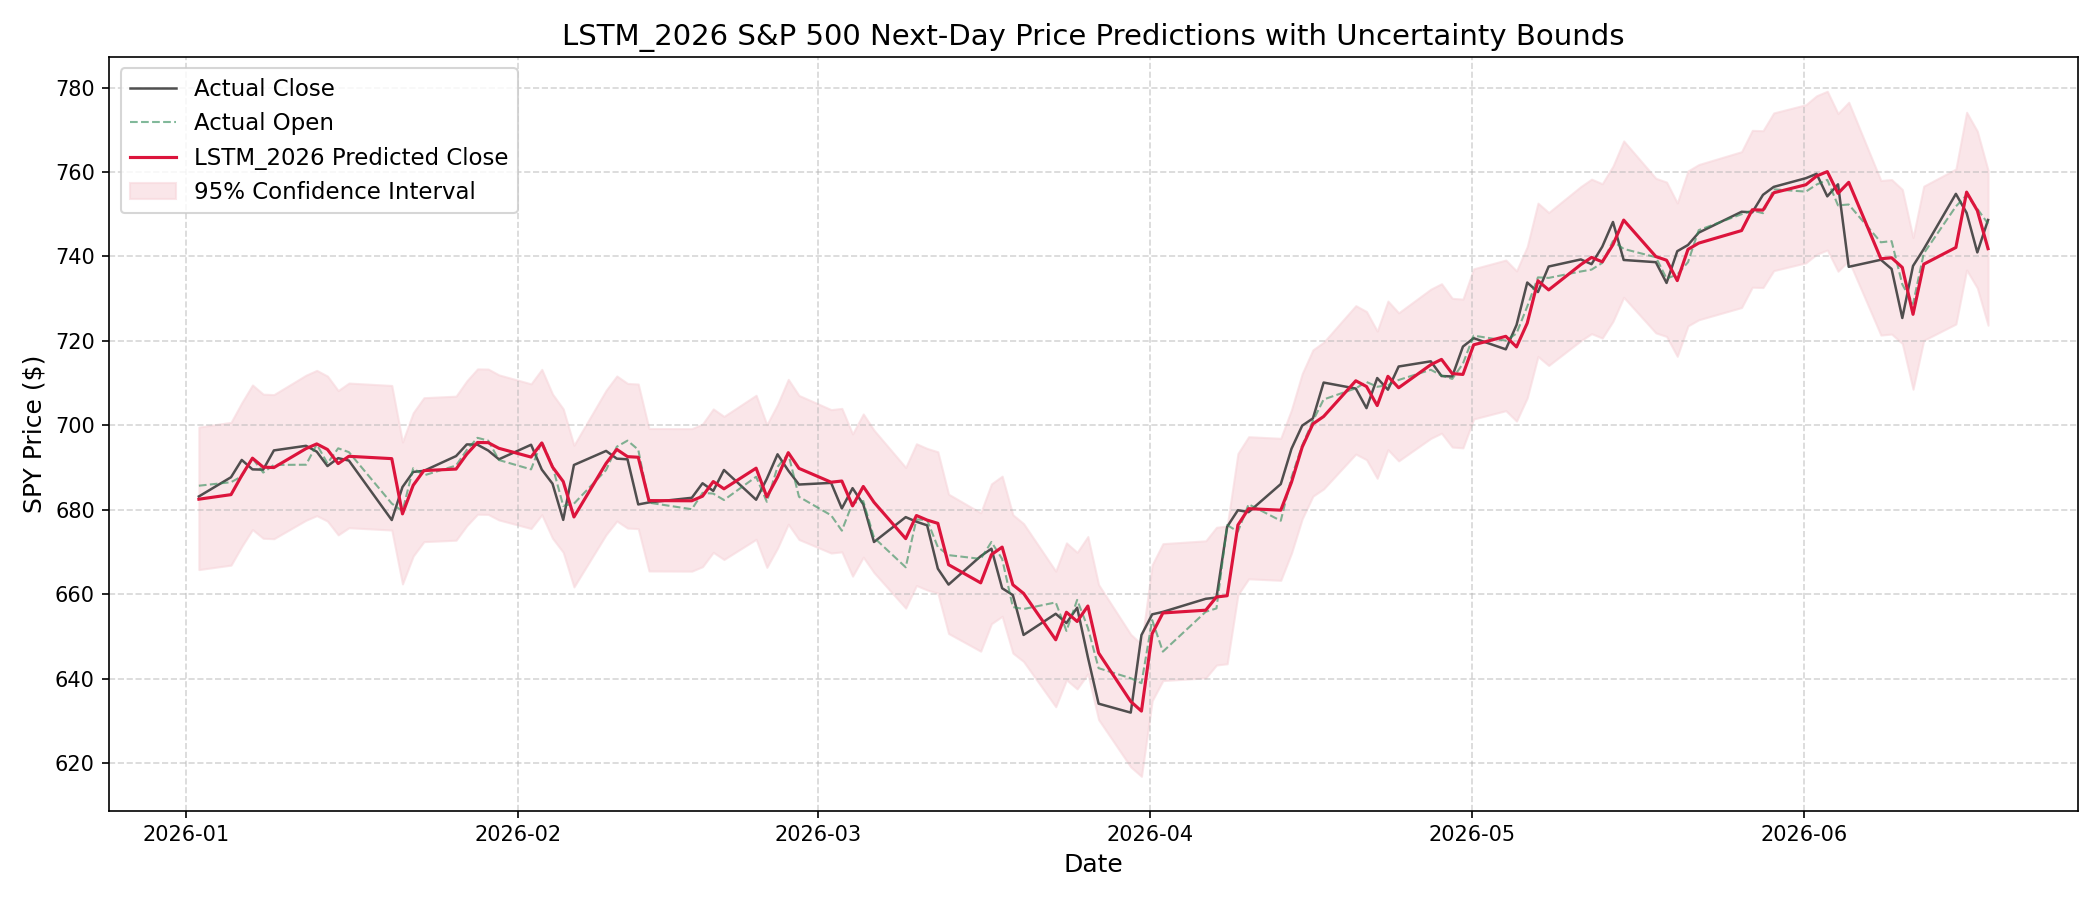

In [17]:
X_cur, y_cur, dates_cur = build_year_sequences(
    raw_cur, scaler, year=current_year
)
prev_close_cur, open_cur = aligned_prices(raw_cur, dates_cur)

for name, model in [("VariationalGP", vgp), ("LSTM", lstm)]:
    results = scaled_results(model, X_cur, y_cur)
    plotting.plot_price_predictions(
        f"{name}_{current_year}",
        results,
        scaler,
        prev_close_cur,
        actual_open=open_cur,
        dates=dates_cur.to_numpy(),
        max_points=len(dates_cur),
    )
    display(
        Image(
            filename=str(
                RESULTS_DIR / f"{name}_{current_year}_price_predictions.png"
            )
        )
    )

### Projecting to year-end

Starting from the latest real window, we autoregressively sample the next-day return from the model's own predictive distribution, append it, recompute the volatility features from the simulated path, and repeat to 31 Dec.

Projecting 140 trading days: 2026-06-19 -> 2026-12-31


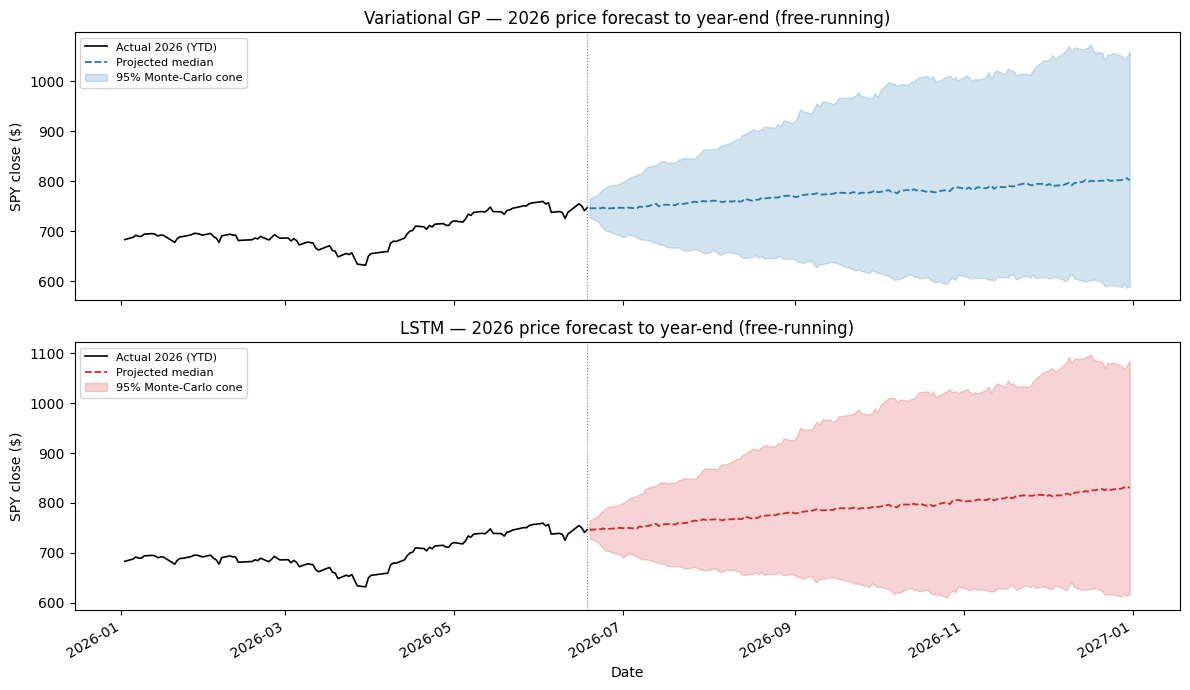

In [18]:
def recent_scaled_returns(df: pd.DataFrame, scaler: SPYScaler) -> pd.DataFrame:
    d = df.copy()
    d["Date"] = pd.to_datetime(d["Date"], utc=True)
    d = d.sort_values("Date").reset_index(drop=True)
    div = d["Dividends"].fillna(0.0)
    d["Log_Return"] = np.log((d["Close"] + div) / d["Close"].shift(1))
    d = d.dropna().reset_index(drop=True)
    d["Scaled"] = (d["Log_Return"] - scaler.mean) / scaler.scale
    return d


def rollout_to_year_end(
    model: BaseModel,
    history_returns: np.ndarray,
    last_close: float,
    n_steps: int,
    window_size: int = WINDOW_SIZE,
    n_paths: int = 300,
    seed: int = 0,
) -> dict[str, np.ndarray]:
    rng = np.random.default_rng(seed)
    seed_len = window_size + 21
    R = np.tile(history_returns[-seed_len:].astype(np.float64), (n_paths, 1))

    def feature_window(R: np.ndarray) -> torch.Tensor:
        """Build the [paths, window, 4] feature tensor from the latest returns."""
        n_paths, length = R.shape
        win = np.empty((n_paths, window_size, 4), dtype=np.float32)
        for k in range(window_size):
            p = length - window_size + k
            r = R[:, p]
            win[:, k, 0] = r
            win[:, k, 1] = np.abs(r)
            win[:, k, 2] = R[:, p - 4 : p + 1].std(axis=1, ddof=1)
            win[:, k, 3] = R[:, p - 20 : p + 1].std(axis=1, ddof=1)
        return torch.tensor(win, device=DEVICE)

    sampled = np.empty((n_paths, n_steps), dtype=np.float64)
    for t in range(n_steps):
        dist = model.forward_pass(feature_window(R))
        mean = dist.mean.detach().cpu().numpy()
        std = np.sqrt(dist.variance.detach().cpu().numpy())
        r_next = rng.normal(mean, std)
        sampled[:, t] = r_next
        R = np.concatenate([R, r_next[:, None]], axis=1)

    raw = sampled * scaler.scale + scaler.mean
    price = last_close * np.exp(np.cumsum(raw, axis=1))
    return {
        "median": np.median(price, axis=0),
        "lower": np.percentile(price, 2.5, axis=0),
        "upper": np.percentile(price, 97.5, axis=0),
    }


hist = recent_scaled_returns(raw_cur, scaler)
last_close = float(hist["Close"].iloc[-1])
last_date = hist["Date"].iloc[-1]
future_dates = pd.bdate_range(
    (last_date + pd.Timedelta(days=1)).tz_localize(None),
    f"{current_year}-12-31",
).tz_localize("UTC")
ytd = hist[hist["Date"].dt.year == current_year]

print(
    f"Projecting {len(future_dates)} trading days: "
    f"{future_dates.min().date()} -> {future_dates.max().date()}"
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
panels = [("Variational GP", vgp, "tab:blue"), ("LSTM", lstm, "tab:red")]
for ax, (name, model, color) in zip(axes, panels):
    roll = rollout_to_year_end(
        model, hist["Scaled"].to_numpy(), last_close, len(future_dates)
    )
    ax.plot(
        ytd["Date"],
        ytd["Close"],
        color="black",
        lw=1.2,
        label=f"Actual {current_year} (YTD)",
    )
    ax.plot(
        future_dates,
        roll["median"],
        color=color,
        lw=1.3,
        ls="--",
        label="Projected median",
    )
    ax.fill_between(
        future_dates,
        roll["lower"],
        roll["upper"],
        color=color,
        alpha=0.2,
        label="95% Monte-Carlo cone",
    )
    ax.axvline(last_date, color="grey", lw=0.8, ls=":")
    ax.set_title(
        f"{name} — {current_year} price forecast to year-end (free-running)"
    )
    ax.set_ylabel("SPY close ($)")
    ax.legend(loc="upper left", fontsize=8)
axes[1].set_xlabel("Date")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## (Bonus) Predicting the next trading day

We take the most recent observed 21-day window and predict the return for the next trading day, which has not happened yet. We fetch a short recent slice (enough for one 21-day window plus the rolling-volatility lookback), build the final window, and report the predicted next-day return with its 95% confidence interval. For daily returns the mean is expected to sit near zero as the model's real signal lives in the width of that interval, not a confident directional call.

In [19]:
def latest_window(
    df: pd.DataFrame, scaler: SPYScaler, window_size: int = WINDOW_SIZE
) -> tuple[torch.Tensor, pd.Timestamp, float]:
    """Build the single most-recent input window and return (X, last_date, last_close).

    The prediction it feeds is for the trading day *after* `last_date`.
    """
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], utc=True)
    df = df.sort_values("Date").reset_index(drop=True)

    div = df["Dividends"].fillna(0.0)
    df["Log_Return"] = np.log((df["Close"] + div) / df["Close"].shift(1))
    df = df.dropna().reset_index(drop=True)
    df["Scaled_Log_Return"] = (df["Log_Return"] - scaler.mean) / scaler.scale
    df["Abs_Log_Return"] = df["Scaled_Log_Return"].abs()
    df["Vol_5d"] = df["Scaled_Log_Return"].rolling(5).std()
    df["Vol_21d"] = df["Scaled_Log_Return"].rolling(21).std()
    df = df.dropna().reset_index(drop=True)

    feats = ["Scaled_Log_Return", "Abs_Log_Return", "Vol_5d", "Vol_21d"]
    X = np.ascontiguousarray(df[feats].values[-window_size:])[None, ...]
    X_t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    return X_t, df.iloc[-1]["Date"], float(df.iloc[-1]["Close"])


now = pd.Timestamp.now("UTC").normalize()
recent = fetch_spy(
    (now - pd.Timedelta(days=100)).date().isoformat(),
    (now + pd.Timedelta(days=1)).date().isoformat(),
)
X_now, last_date, last_close = latest_window(recent, scaler)
print(f"Last observed close: {last_close:.2f} on {last_date.date()}")
print(f"Forecasting the next trading day after {last_date.date()}\n")

rows = {}
for name, model in [("VariationalGP", vgp), ("LSTM", lstm)]:
    dist = model.forward_pass(X_now)
    mean = float(dist.mean) * scaler.scale + scaler.mean
    std = float(dist.variance**0.5) * scaler.scale
    rows[name] = {
        "Pred return (%)": mean * 100,
        "95% low (%)": (mean - 1.96 * std) * 100,
        "95% high (%)": (mean + 1.96 * std) * 100,
        "95% width (%)": 2 * 1.96 * std * 100,
        "Implied close": last_close * np.exp(mean),
    }

pd.DataFrame(rows).T.round(3)

Last observed close: 746.74 on 2026-06-18
Forecasting the next trading day after 2026-06-18



,Pred return (%),95% low (%),95% high (%),95% width (%),Implied close
VariationalGP,-0.046,-2.592,2.499,5.091,746.393
LSTM,0.056,-2.417,2.530,4.946,747.161
